In [29]:
import time 

import cv2
import IPython
import face_recognition
import dlib

In [12]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [3]:
img = cv2.imread('../images/img_1.jpg')

In [5]:
landmarks = face_recognition.face_landmarks(img, model='small')
landmarks

[{'nose_tip': [(364, 353)],
  'left_eye': [(245, 229), (318, 236)],
  'right_eye': [(494, 237), (423, 239)]}]

In [6]:
landmarks[0]['left_eye', 'right_eye']

KeyError: ('left_eye', 'right_eye')

In [8]:
{k: v for k, v in landmarks[0].items() if k in ['left_eye', 'right_eye']}

{'left_eye': [(245, 229), (318, 236)], 'right_eye': [(494, 237), (423, 239)]}

In [9]:
for k, v in landmarks[0].items():
    for i in v:
        cv2.circle(img, i, 5, (0, 0, 255), -1)

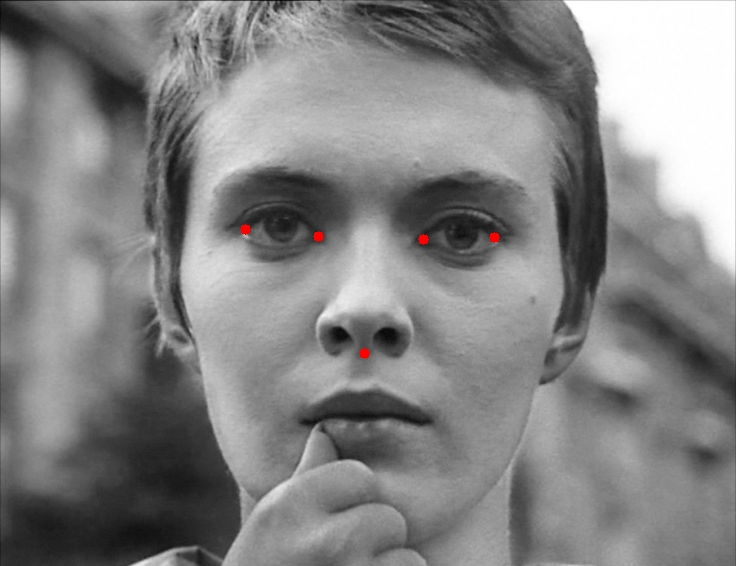

In [13]:
show_image(img)

In [54]:
t = time.time()
img = cv2.imread('../images/img_1.jpg')
b = face_recognition.face_locations(img)
b
print(time.time() - t)

0.16587018966674805


In [55]:
t = time.time()
e = face_recognition.face_encodings(img, known_face_locations=b)
e
print(time.time() - t)

0.07900619506835938


In [39]:
t = time.time()
e = face_recognition.face_encodings(img)
e
print(time.time() - t)

0.2348952293395996


In [40]:
t = time.time()
for i in b:
    e = face_recognition.face_encodings(img, known_face_locations=[i])
print(time.time() - t)

0.078094482421875


In [27]:
i

(122, 885, 158, 853)

In [43]:
detector = dlib.get_frontal_face_detector()
rec = dlib.face_recognition_model_v1('../data/dlib_face_recognition_resnet_model_v1.dat')
sp = dlib.shape_predictor('../data/shape_predictor_5_face_landmarks.dat')

In [46]:
for d in dets:
    print(d)

[(161, 119) (546, 504)]


In [52]:
dets = detector(img, 1)
for d in dets:
    shape = sp(img, d)
    t = time.time()
    rec.compute_face_descriptor(img, shape)
    print(time.time() - t)

0.0749049186706543


0.07799291610717773
